# Amazon Sales Data Analysis

## Data Inspection & Data Cleaning

### Objective

Inspect, assess, and clean the Amazon Sales dataset to prepare it for Exploratory Data Analysis (EDA), SQL analysis, and Power BI dashboard development.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)

In [2]:
from google.colab import files

uploaded = files.upload()

Saving Amazon Sale Report.csv to Amazon Sale Report.csv


In [3]:
df = pd.read_csv("Amazon Sale Report.csv")

In [4]:
original_columns = df.columns.tolist()

df.columns = (
    df.columns
      .str.strip()
      .str.lower()
      .str.replace(" ", "_", regex=False)
      .str.replace("-", "_", regex=False)
)

column_mapping = pd.DataFrame({
    "Original Column": original_columns,
    "New Column": df.columns
})

column_mapping

,Original Column,New Column
0,index,index
1,Order ID,order_id
2,Date,date
3,Status,status
4,Fulfilment,fulfilment
5,Sales Channel,sales_channel
6,ship-service-level,ship_service_level
7,Category,category
8,Size,size
9,Courier Status,courier_status


In [5]:
df.head()

,index,order_id,date,status,fulfilment,sales_channel,ship_service_level,category,size,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,b2b,fulfilled_by,new,pendings
0,0,405-8078784-5731545,04-30-22,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,0,INR,647.62,MUMBAI,MAHARASHTRA,400081.0,IN,False,Easy Ship,NaN,NaN
1,1,171-9198151-1101146,04-30-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085.0,IN,False,Easy Ship,NaN,NaN
2,2,404-0687676-7273146,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210.0,IN,True,NaN,NaN,NaN
3,3,403-9615377-8133951,04-30-22,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008.0,IN,False,Easy Ship,NaN,NaN
4,4,407-1069790-7240320,04-30-22,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073.0,IN,False,NaN,NaN,NaN


In [6]:
df.sample(5, random_state=42)

,index,order_id,date,status,fulfilment,sales_channel,ship_service_level,category,size,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,b2b,fulfilled_by,new,pendings
98165,98164,405-2539019-7739511,06-23-22,Shipped,Amazon,Amazon.in,Expedited,Shirt,XXL,Shipped,1,INR,436.0,GURUGRAM,HARYANA,122001.0,IN,False,NaN,NaN,NaN
8776,8775,171-9423437-6005132,04-25-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Trousers,XL,Shipped,1,INR,540.0,"Carona, Aldona",GOA,403523.0,IN,False,Easy Ship,NaN,NaN
114136,114135,171-8653256-5172308,06-11-2022,Shipped,Amazon,Amazon.in,Expedited,Shirt,M,Shipped,1,INR,432.0,TUMAKURU,KARNATAKA,572105.0,IN,False,NaN,NaN,NaN
119795,119794,171-8562396-3904321,06-07-2022,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,T-shirt,S,Shipped,1,INR,1399.0,BHUNTAR,HIMACHAL PRADESH,175125.0,IN,False,Easy Ship,NaN,NaN
69079,69078,404-2183469-8997958,05-15-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,5XL,Shipped,1,INR,925.0,JAIPUR,RAJASTHAN,302004.0,IN,False,Easy Ship,NaN,NaN


In [7]:
df.shape

(128976, 21)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 128976 entries, 0 to 128975
Data columns (total 21 columns):
 #   Column              Non-Null Count   Dtype  
---  ------              --------------   -----  
 0   index               128976 non-null  int64  
 1   order_id            128976 non-null  object 
 2   date                128976 non-null  object 
 3   status              128976 non-null  object 
 4   fulfilment          128976 non-null  object 
 5   sales_channel       128976 non-null  object 
 6   ship_service_level  128976 non-null  object 
 7   category            128976 non-null  object 
 8   size                128976 non-null  object 
 9   courier_status      128976 non-null  object 
 10  qty                 128976 non-null  int64  
 11  currency            121176 non-null  object 
 12  amount              121176 non-null  float64
 13  ship_city           128941 non-null  object 
 14  ship_state          128941 non-null  object 
 15  ship_postal_code    128941 non-nul

In [9]:
df.describe()

,index,qty,amount,ship_postal_code,new,pendings
count,128976.000000,128976.000000,121176.000000,128941.000000,0.0,0.0
mean,64486.130427,0.904401,648.562176,463945.677744,NaN,NaN
std,37232.897832,0.313368,281.185041,191458.488954,NaN,NaN
min,0.000000,0.000000,0.000000,110001.000000,NaN,NaN
25%,32242.750000,1.000000,449.000000,382421.000000,NaN,NaN
50%,64486.500000,1.000000,605.000000,500033.000000,NaN,NaN
75%,96730.250000,1.000000,788.000000,600024.000000,NaN,NaN
max,128974.000000,15.000000,5584.000000,989898.000000,NaN,NaN


In [10]:
df.describe(include="object")

,order_id,date,status,fulfilment,sales_channel,ship_service_level,category,size,courier_status,currency,ship_city,ship_state,ship_country,fulfilled_by
count,128976,128976,128976,128976,128976,128976,128976,128976,128976,121176,128941,128941,128941,39263
unique,120229,91,13,2,2,2,9,11,4,1,8948,69,1,1
top,403-4984515-8861958,05-03-2022,Shipped,Amazon,Amazon.in,Expedited,T-shirt,M,Shipped,INR,BENGALURU,MAHARASHTRA,IN,Easy Ship
freq,12,2085,77815,89713,128852,88630,50292,22373,109486,121176,11208,22272,128941,39263


## Data Quality Assessment

In [11]:
missing = pd.DataFrame({
    "Missing Values": df.isnull().sum(),
    "Percentage (%)": (df.isnull().mean()*100).round(2)
})

missing.sort_values("Percentage (%)", ascending=False)

,Missing Values,Percentage (%)
pendings,128976,100.00
new,128976,100.00
fulfilled_by,89713,69.56
currency,7800,6.05
amount,7800,6.05
ship_state,35,0.03
ship_city,35,0.03
ship_postal_code,35,0.03
ship_country,35,0.03
index,0,0.00


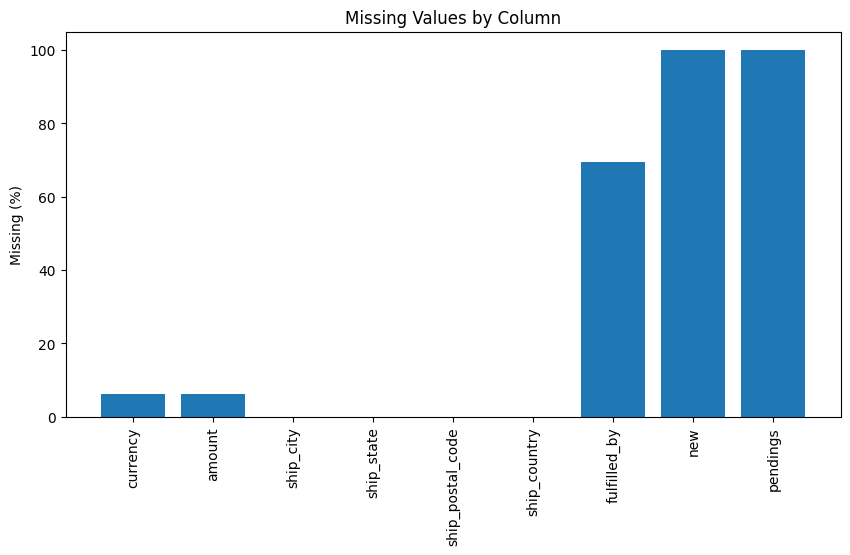

In [12]:
missing = missing[missing["Missing Values"] > 0]

plt.figure(figsize=(10,5))
plt.bar(missing.index, missing["Percentage (%)"])
plt.xticks(rotation=90)
plt.ylabel("Missing (%)")
plt.title("Missing Values by Column")
plt.show()

In [13]:
df.duplicated().sum()

np.int64(168)

In [14]:
pd.DataFrame({
    "Data Type": df.dtypes,
    "Unique Values": df.nunique(),
    "Missing Values": df.isnull().sum()
})

,Data Type,Unique Values,Missing Values
index,int64,128808,0
order_id,object,120229,0
date,object,91,0
status,object,13,0
fulfilment,object,2,0
sales_channel,object,2,0
ship_service_level,object,2,0
category,object,9,0
size,object,11,0
courier_status,object,4,0


## Column Inspection

In [15]:
for col in df.columns:
    print("="*80)
    print(col.upper())
    print("="*80)
    print(df[col].value_counts(dropna=False).head(10))
    print()

INDEX
index
3867    2
3866    2
3865    2
3864    2
3863    2
3862    2
3861    2
3860    2
3859    2
6278    2
Name: count, dtype: int64

ORDER_ID
order_id
403-4984515-8861958    12
171-5057375-2831560    12
403-0173977-3041148    11
404-9932919-6662730    11
408-3317403-1729937    10
171-0706521-2133101     9
408-2964501-8373155     9
404-3701762-8241125     9
406-9002076-4152331     9
171-4310662-2005103     9
Name: count, dtype: int64

DATE
date
05-03-2022    2085
05-02-2022    2079
05-04-2022    2015
04-14-22      1883
04-15-22      1853
04-20-22      1850
04-23-22      1816
04-24-22      1810
05-01-2022    1809
04-16-22      1759
Name: count, dtype: int64

STATUS
status
Shipped                          77815
Shipped - Delivered to Buyer     28756
Cancelled                        18334
Shipped - Returned to Seller      1954
Shipped - Picked Up                973
Pending                            658
Pending - Waiting for Pick Up      281
Shipped - Returning to Seller      145
Shi

In [16]:
numeric_columns = df.select_dtypes(include=np.number).columns

df[numeric_columns].describe().T

,count,mean,std,min,25%,50%,75%,max
index,128976.0,64486.130427,37232.897832,0.0,32242.75,64486.5,96730.25,128974.0
qty,128976.0,0.904401,0.313368,0.0,1.00,1.0,1.00,15.0
amount,121176.0,648.562176,281.185041,0.0,449.00,605.0,788.00,5584.0
ship_postal_code,128941.0,463945.677744,191458.488954,110001.0,382421.00,500033.0,600024.00,989898.0
new,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
pendings,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [17]:
categorical_columns = df.select_dtypes(include="object").columns

df[categorical_columns].describe().T

,count,unique,top,freq
order_id,128976,120229,403-4984515-8861958,12
date,128976,91,05-03-2022,2085
status,128976,13,Shipped,77815
fulfilment,128976,2,Amazon,89713
sales_channel,128976,2,Amazon.in,128852
ship_service_level,128976,2,Expedited,88630
category,128976,9,T-shirt,50292
size,128976,11,M,22373
courier_status,128976,4,Shipped,109486
currency,121176,1,INR,121176


## Data Cleaning

The dataset contains missing values, inconsistent date formats, and a few unnecessary columns. Each issue will be handled based on its business relevance to preserve as much useful information as possible.

In [18]:
df.drop(columns=["new", "pendings"], inplace=True)

In [19]:
df.columns.tolist()

['index',
 'order_id',
 'date',
 'status',
 'fulfilment',
 'sales_channel',
 'ship_service_level',
 'category',
 'size',
 'courier_status',
 'qty',
 'currency',
 'amount',
 'ship_city',
 'ship_state',
 'ship_postal_code',
 'ship_country',
 'b2b',
 'fulfilled_by']

In [20]:
df.drop_duplicates(inplace=True)

In [21]:
df.duplicated().sum()

np.int64(0)

In [22]:
df["date"] = pd.to_datetime(
    df["date"],
    errors="coerce",
    format="mixed"
)

In [23]:
df["date"].dtype

dtype('<M8[ns]')

In [24]:
df["date"].isnull().sum()

np.int64(0)

In [25]:
df["currency"] = df["currency"].fillna("INR")

In [26]:
df["currency"].isnull().sum()

np.int64(0)

In [27]:
df[df["amount"].isnull()]["status"].value_counts()

,count
status,
Cancelled,7560
Shipped,208
Shipped - Delivered to Buyer,8
Shipping,8
Shipped - Returned to Seller,3
Pending,2


In [28]:
df[
    (df["amount"].isnull()) &
    (df["status"] != "Cancelled")
][["order_id", "status", "qty", "currency", "fulfilment", "courier_status"]].head(20)

,order_id,status,qty,currency,fulfilment,courier_status
938,S02-5278980-4327051,Shipped,15,INR,Amazon,Unshipped
1058,S02-9107114-0460608,Shipped,2,INR,Amazon,Unshipped
1616,405-7790745-1369118,Shipped,0,INR,Amazon,Cancelled
1990,171-9673855-2321133,Shipped,0,INR,Amazon,Cancelled
2425,404-7478762-7926753,Shipped,0,INR,Amazon,Cancelled
2820,404-0814480-8157169,Shipped,0,INR,Amazon,Cancelled
3632,S02-1006261-5356758,Shipped,9,INR,Amazon,Unshipped
3633,S02-3681731-6111841,Shipped,1,INR,Amazon,Unshipped
3635,S02-1926028-4838217,Shipped,1,INR,Amazon,Unshipped
3637,S02-6828927-1180856,Shipped,13,INR,Amazon,Unshipped


In [29]:
df[
    (df["amount"].isnull()) &
    (df["status"] != "Cancelled")
].shape

(229, 19)

In [30]:
df = df[
    ~(
        (df["amount"].isnull()) &
        (df["status"] != "Cancelled")
    )
]

In [31]:
df["amount"] = df["amount"].fillna(0)

In [32]:
df["amount"].isnull().sum()

np.int64(0)

## Handle Missing Values

In [33]:
df["currency"] = df["currency"].fillna("INR")

In [34]:
df["currency"].value_counts(dropna=False)

,count
currency,
INR,128579


In [35]:
df = df[
    ~(
        (df["amount"].isnull()) &
        (df["status"] != "Cancelled")
    )
]

In [36]:
df["amount"] = df["amount"].fillna(0)

In [37]:
df["amount"].isnull().sum()

np.int64(0)

In [38]:
df["ship_city"] = df["ship_city"].fillna("Unknown")
df["ship_state"] = df["ship_state"].fillna("Unknown")
df["ship_country"] = df["ship_country"].fillna("Unknown")

In [39]:
df["ship_postal_code"] = df["ship_postal_code"].fillna(0)
df["ship_postal_code"] = df["ship_postal_code"].astype(int)

In [40]:
df["fulfilled_by"].value_counts(dropna=False)

,count
fulfilled_by,
NaN,89377
Easy Ship,39202


In [41]:
df["fulfilled_by"] = df["fulfilled_by"].fillna("Amazon")

In [42]:
df["fulfilled_by"].value_counts(dropna=False)

,count
fulfilled_by,
Amazon,89377
Easy Ship,39202


## Standardize Data Types

In [43]:
df.dtypes

,0
index,int64
order_id,object
date,datetime64[ns]
status,object
fulfilment,object
sales_channel,object
ship_service_level,object
category,object
size,object
courier_status,object


In [44]:
df["date"] = pd.to_datetime(
    df["date"],
    format="mixed",
    errors="coerce"
)

In [45]:
df["date"].dtype

dtype('<M8[ns]')

## Feature Engineering

In [46]:
df["year"] = df["date"].dt.year
df["month"] = df["date"].dt.month_name()
df["month_number"] = df["date"].dt.month
df["day"] = df["date"].dt.day
df["day_name"] = df["date"].dt.day_name()
df["quarter"] = df["date"].dt.quarter

In [47]:
df.head()

,index,order_id,date,status,fulfilment,sales_channel,ship_service_level,category,size,courier_status,qty,currency,amount,ship_city,ship_state,ship_postal_code,ship_country,b2b,fulfilled_by,year,month,month_number,day,day_name,quarter
0,0,405-8078784-5731545,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,T-shirt,S,On the Way,0,INR,647.62,MUMBAI,MAHARASHTRA,400081,IN,False,Easy Ship,2022,April,4,30,Saturday,2
1,1,171-9198151-1101146,2022-04-30,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,Shirt,3XL,Shipped,1,INR,406.00,BENGALURU,KARNATAKA,560085,IN,False,Easy Ship,2022,April,4,30,Saturday,2
2,2,404-0687676-7273146,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Shirt,XL,Shipped,1,INR,329.00,NAVI MUMBAI,MAHARASHTRA,410210,IN,True,Amazon,2022,April,4,30,Saturday,2
3,3,403-9615377-8133951,2022-04-30,Cancelled,Merchant,Amazon.in,Standard,Blazzer,L,On the Way,0,INR,753.33,PUDUCHERRY,PUDUCHERRY,605008,IN,False,Easy Ship,2022,April,4,30,Saturday,2
4,4,407-1069790-7240320,2022-04-30,Shipped,Amazon,Amazon.in,Expedited,Trousers,3XL,Shipped,1,INR,574.00,CHENNAI,TAMIL NADU,600073,IN,False,Amazon,2022,April,4,30,Saturday,2


## Final Data Quality Check

In [48]:
pd.DataFrame({
    "Data Type": df.dtypes,
    "Missing Values": df.isnull().sum()
})

,Data Type,Missing Values
index,int64,0
order_id,object,0
date,datetime64[ns],0
status,object,0
fulfilment,object,0
sales_channel,object,0
ship_service_level,object,0
category,object,0
size,object,0
courier_status,object,0


In [49]:
df.duplicated().sum()

np.int64(0)

In [50]:
df.shape

(128579, 25)

In [54]:
df.drop(columns="index", inplace=True)

## Export Clean Dataset

In [55]:
df.to_csv("Amazon_Sales_Cleaned.csv", index=False)

In [56]:
from google.colab import files

files.download("Amazon_Sales_Cleaned.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

## Cleaning Summary

- Removed irrelevant columns (`new`, `pendings`).
- Removed duplicate records.
- Standardized column names.
- Converted the `date` column to datetime format.
- Filled missing values based on business logic.
- Created new time-based features for analysis.
- Exported the cleaned dataset for EDA, SQL, and Power BI.

In [53]:
pd.crosstab(
    df["fulfilment"],
    df["fulfilled_by"],
    dropna=False
)

fulfilled_by,Amazon,Easy Ship
fulfilment,,
Amazon,89377,0
Merchant,0,39202
